<a href="https://colab.research.google.com/github/Alex-Devoid/ST554-HW/blob/main/HW6/HW6_Alex_Devoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW6 — SQL Practice and Classes

Name: Alex Devoid  
Course: ST 554

## Part I — More Practice Querying a Database

In [86]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) Look at all of the tables in the database
Connecting to the Lahman SQLite database and looking at all of the tables in the database.
`pd.read_sql()` willl return the results as a pandas data frame.


In [87]:


DB_FILE = "/content/lahman_1871-2022.sqlite"

# sqlite3.connect() opens the database file so SQL queries can be sent to it
conn = sqlite3.connect(DB_FILE)

In [88]:
# Look at all tables in the database
# sqlite_schema is SQLite's catalog table, so querying it lets us list the tables in the database
tables_df = pd.read_sql("""
SELECT name
FROM sqlite_schema
WHERE type = 'table';
""", conn)

tables_df

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


### 2.

Hall of Fame pitchers

For this part, I want Hall of Famers who pitched and their total values for:
- `GS`
- `G`
- `W`
- `L`
- `IPOuts`
- `CG`
- `SHO`
- `SV`

I am including regular season and postseason pitching records.

In [89]:
# Hall of Fame pitchers and pitching rows
# useing SQL first to filter down to the right players and rows,
# then useing pandas to total the stats into one row per pitcher

hof_pitching_raw = pd.read_sql("""
SELECT
    -- SELECT is used to choose only the columns we actually need
    hp.playerID,
    p.GS,
    p.G,
    p.W,
    p.L,
    p.IPOuts,
    p.CG,
    p.SHO,
    p.SV
FROM (
    SELECT DISTINCT h.playerID
    -- DISTINCT is used so each Hall of Fame pitcher appears only once here
    FROM HallOfFame AS h
    INNER JOIN (
        SELECT DISTINCT playerID
        FROM Pitching
        UNION
        SELECT DISTINCT playerID
        FROM PitchingPost
        -- UNION is used here to combine pitcher IDs from both tables and remove duplicates
    ) AS p_ids
        ON h.playerID = p_ids.playerID
        -- INNER JOIN is used to keep only players who are in both the HallOfFame table and the pitching ID list
    WHERE h.inducted = 'Y'
    -- WHERE is used to filter to players who were actually inducted into the Hall of Fame
) AS hp
LEFT JOIN (
    SELECT playerID, GS, G, W, L, IPOuts, CG, SHO, SV
    FROM Pitching
    UNION ALL
    SELECT playerID, GS, G, W, L, IPOuts, CG, SHO, SV
    FROM PitchingPost
    -- UNION ALL is used here instead of UNION because we want to keep every stat row from both regular season and postseason so we can total all of them later
) AS p
    ON hp.playerID = p.playerID
    -- LEFT JOIN is used so every Hall of Fame pitcher stays in the result
;
""", conn)

# these are the pitching columns we want to total for each pitcher
pitch_cols = ["GS", "G", "W", "L", "IPOuts", "CG", "SHO", "SV"]

hof_pitching = (
    hof_pitching_raw

    .fillna({col: 0 for col in pitch_cols})
    # groupby is used to collapse multiple rows per pitcher into one row

    .groupby("playerID", as_index=False)[pitch_cols]
    .sum()
)

hof_pitching.head(), hof_pitching.shape

(    playerID   GS    G    W    L  IPOuts   CG  SHO  SV
 0  alexape01  604  703  376  210   15699  441   90  33
 1  ansonca01    0    3    0    1      12    0    0   1
 2  becklja01    1    1    0    1      12    0    0   0
 3  bendech01  344  469  218  131    9306  264   41  34
 4  blylebe01  691  700  292  251   15052  243   60   0,
 (108, 9))

### 3.

Hall of Fame pitcher batting statistics

Now I create a batting table for those same Hall of Fame pitchers.

The batting totals are for:
- `AB`
- `R`
- `H`
- `HR`
- `RBI`
- `BB`
- `SO`

Again, I am including regular season and postseason batting records.


In [90]:
# Hall of Fame pitchers and batting rows
# Using SQL first to identify the Hall of Fame pitchers and pull all of their batting rows,
# Then using pandas to total those batting stats into one row per pitcher

hof_batting_raw = pd.read_sql("""
SELECT
    -- SELECT is used to choose only the batting columns we need
    hp.playerID,
    b.AB,
    b.R,
    b.H,
    b.HR,
    b.RBI,
    b.BB,
    b.SO
FROM (
    SELECT DISTINCT h.playerID
    -- DISTINCT is used so each Hall of Fame pitcher appears only once here
    FROM HallOfFame AS h
    INNER JOIN (
        SELECT DISTINCT playerID
        FROM Pitching
        UNION
        SELECT DISTINCT playerID
        FROM PitchingPost
        -- UNION is used to combine pitcher IDs from both pitching tables and remove duplicates because here we only need one list of pitchers
    ) AS p_ids
        ON h.playerID = p_ids.playerID
        -- INNER JOIN is used to keep only players who are both Hall of Famers and players who pitched
    WHERE h.inducted = 'Y'
    -- WHERE is used to keep only inducted Hall of Fame players
) AS hp
LEFT JOIN (
    SELECT playerID, AB, R, H, HR, RBI, BB, SO
    FROM Batting
    UNION ALL
    SELECT playerID, AB, R, H, HR, RBI, BB, SO
    FROM BattingPost
    -- UNION ALL is used here because we want every batting row from both tables so the later totals include both regular season and postseason batting stats
) AS b
    ON hp.playerID = b.playerID
    -- LEFT JOIN is used so every Hall of Fame pitcher stays in the result,
    -- even if a player has missing batting rows or missing batting values
;
""", conn)

# these are the batting columns we want to total for each pitcher
bat_cols = ["AB", "R", "H", "HR", "RBI", "BB", "SO"]

hof_batting = (
    hof_batting_raw
    # fillna(0) is used so missing batting values count as 0 when we total them
    .fillna({col: 0 for col in bat_cols})
    # groupby is used to combine all batting rows for the same pitcher
    # sum is used because the homework asks for total batting statistics
    .groupby("playerID", as_index=False)[bat_cols]
    .sum()
)

hof_batting.head(), hof_batting.shape

(    playerID     AB     R     H  HR     RBI   BB     SO
 0  alexape01   1823   155   379  11   164.0   77  279.0
 1  ansonca01  10328  2010  3451  97  2076.0  990  330.0
 2  becklja01   9551  1603  2938  87  1581.0  616  526.0
 3  bendech01   1179   103   246   6   118.0   76  147.0
 4  blylebe01    458    20    60   0    25.0    5  195.0,
 (108, 8))

### 4.

Join the two Hall of Fame pitcher tables together by pitcher.

I am using `pd.merge()` on `playerID`.

In [91]:
# Join the pitching and batting tables together by pitcher
# pd.merge() matches rows from the two tables using the shared playerID key
hof_pitchers_full = pd.merge(hof_pitching, hof_batting, on="playerID", how="inner")

hof_pitchers_full.head(), hof_pitchers_full.shape

(    playerID   GS    G    W    L  IPOuts   CG  SHO  SV     AB     R     H  HR  \
 0  alexape01  604  703  376  210   15699  441   90  33   1823   155   379  11   
 1  ansonca01    0    3    0    1      12    0    0   1  10328  2010  3451  97   
 2  becklja01    1    1    0    1      12    0    0   0   9551  1603  2938  87   
 3  bendech01  344  469  218  131    9306  264   41  34   1179   103   246   6   
 4  blylebe01  691  700  292  251   15052  243   60   0    458    20    60   0   
 
       RBI   BB     SO  
 0   164.0   77  279.0  
 1  2076.0  990  330.0  
 2  1581.0  616  526.0  
 3   118.0   76  147.0  
 4    25.0    5  195.0  ,
 (108, 16))

In [92]:
# close the database connection
conn.close()


## Part II — Messing with Classes

### 5.

The class itself is in `SLR_slope_simulator.py`.  
Bellow I'm just importing the class and testing it.


In [93]:
# Import the class file
from SLR_slope_simulator import SLR_slope_simulator

In [94]:
# create the x values
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)


# create the simulator object
sim = SLR_slope_simulator(
    beta_0=12,
    beta_1=2,
    x=x,
    sigma=1,
    seed=10
)

In [95]:
# call the plot method before simulations
# this checks whether the slopes attribute has been filled yet
sim.plot_sampling_distribution()

run_simulations() must be called first.


In [96]:
# then run the simulations and produce the requested results
sim.run_simulations(10000)

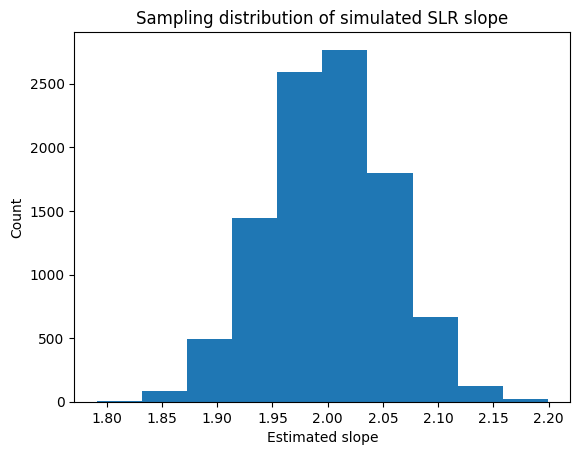

In [97]:
# plot the simulated sampling distribution
# this histogram is using the saved slope estimates as an approximation to the sampling distribution
sim.plot_sampling_distribution()

In [98]:
# approximate the two-sided probability for 2.1
# this uses the simulated slopes and the class's two-sided rule to estimate a probability
prob_two_sided = sim.find_prob(2.1, sided="two-sided")
print("Approximate two-sided probability for 2.1:", prob_two_sided)

Approximate two-sided probability for 2.1: 0.0704


In [99]:
# print the simulated slopes attribute
print(sim.slopes)

[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]
